In [ ]:
!pip install transformers torchvision pillow tqdm nltk matplotlib

In [ ]:
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip

!unzip -q Flickr8k_Dataset.zip
!unzip -q Flickr8k_text.zip

In [ ]:
import torch
import pandas as pd
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import BlipProcessor, BlipForConditionalGeneration
from torch.optim import AdamW
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [ ]:
data = []

with open("Flickr8k.token.txt", 'r') as f:
    for line in f:
        parts = line.strip().split('\t') #removes the caption number
        if len(parts) != 2:
            continue

        img_caption, caption = parts
        img = img_caption.split('#')[0]

        data.append((img, caption)) #image1,caption2   image1,caption2

df = pd.DataFrame(data, columns=["image", "caption"])
print("Total rows:", len(df))

Total rows: 40460


In [ ]:
valid_rows = []

for _, row in df.iterrows():
    img_path = os.path.join("Flicker8k_Dataset", row['image'])

    if not os.path.exists(img_path):
        continue

    try:
        img = Image.open(img_path) #removes corrupted images
        img.verify()
        valid_rows.append(row)
    except:
        continue

df_clean = pd.DataFrame(valid_rows)

print("After cleaning:", len(df_clean))

After cleaning: 40455


In [ ]:
df_small = df_clean.sample(3000, random_state=42).reset_index(drop=True) #3000 because less compute obv

In [ ]:
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [ ]:
for param in model.vision_model.parameters():
    param.requires_grad = False

print("Vision encoder frozen ")

Vision encoder frozen 


In [ ]:
class FlickrDataset(Dataset):
    def __init__(self, df, image_dir, processor):
        self.df = df
        self.image_dir = image_dir
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx] #captures the particular example

        img_path = os.path.join(self.image_dir, row['image'])
        image = Image.open(img_path).convert("RGB")

        encoding = self.processor(  #converts 224,224,3 to 3,224,224 and text into tokens
            images=image,
            text=row['caption'],
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=40
        )

        return {
            "pixel_values": encoding["pixel_values"].squeeze(),
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze()
        }

In [ ]:
dataset = FlickrDataset(df_small, "Flicker8k_Dataset", processor)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

In [ ]:
model.train()

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)

scaler = torch.amp.GradScaler(device="cuda") #uses fp16 instead of fp32

for epoch in range(3):
    total_loss = 0

    loop = tqdm(dataloader, desc=f"Epoch {epoch}")

    for batch in loop:
        input_ids = batch["input_ids"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type="cuda"): #uses float 16 instead of float 32(faster and takes less vram)
            outputs = model( #given image generate these exact caption tokens
                input_ids=input_ids,
                attention_mask=attention_mask,
                pixel_values=pixel_values,
                labels=input_ids
            )
            loss = outputs.loss

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) #prevents explosion of grads
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch} Avg Loss: {total_loss/len(dataloader)}")

Epoch 0: 100%|██████████| 750/750 [02:51<00:00,  4.36it/s, loss=0.457]


Epoch 0 Avg Loss: 1.5745767842928569


Epoch 1: 100%|██████████| 750/750 [02:48<00:00,  4.45it/s, loss=0.541]


Epoch 1 Avg Loss: 0.6162500996987025


Epoch 2: 100%|██████████| 750/750 [02:53<00:00,  4.31it/s, loss=0.5]

Epoch 2 Avg Loss: 0.5379503433505695


In [ ]:
model.save_pretrained("blip-efficient")
processor.save_pretrained("blip-efficient")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['blip-efficient/processor_config.json']

In [ ]:
from collections import defaultdict

refs = defaultdict(list)

for _, row in df_clean.iterrows():
    refs[row['image']].append(row['caption'].split())

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from tqdm import tqdm

smooth = SmoothingFunction().method1

def evaluate_bleu(model, df_eval, num_samples=100):
    scores = []

    loop = tqdm(range(num_samples), desc="Evaluating BLEU")

    for i in loop:
        row = df_eval.iloc[i] #1 image at a time
        img_name = row['image']

        img_path = os.path.join("Flicker8k_Dataset", img_name)
        image = Image.open(img_path).convert("RGB")

        inputs = processor(images=image, return_tensors="pt").to(device)

        output = model.generate(
            **inputs,
            num_beams=5, #instead of generating only 1 path, explores multiple paths and keeps the best 5
            max_length=40
        )

        pred = processor.decode(output[0], skip_special_tokens=True).split() #converts back the nos to words
        references = refs[img_name] #data have multiple captions

        score = sentence_bleu(references, pred, smoothing_function=smooth) #check with all references and calculate bleu
        scores.append(score)

        # show running avg
        loop.set_postfix(avg_bleu=sum(scores)/len(scores))

    print("\nFinal Multi-Reference BLEU:", sum(scores)/len(scores))

In [ ]:
evaluate_bleu(model, df_small, num_samples=100)

Evaluating BLEU: 100%|██████████| 100/100 [00:40<00:00,  2.48it/s, avg_bleu=0.224]


Final Multi-Reference BLEU: 0.22395369017631342


In [ ]:
def show_grid_with_gt(model, df_eval, refs, num_samples=6, cols=3):
    model.eval()

    samples = df_eval.sample(num_samples).reset_index(drop=True)

    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

    axes = axes.flatten()

    for i in range(num_samples):
        row = samples.iloc[i]
        img_name = row['image']
        img_path = os.path.join("Flicker8k_Dataset", img_name)

        image = Image.open(img_path).convert("RGB")

        inputs = processor(images=image, return_tensors="pt").to(device)

        output = model.generate(
            **inputs,
            num_beams=5,
            max_length=40
        )

        pred = processor.decode(output[0], skip_special_tokens=True)
        gt = " ".join(refs[img_name][0])

        axes[i].imshow(image)
        axes[i].axis("off")
        axes[i].set_title(
            f"Pred: {pred}\nGT: {gt}",
            fontsize=8
        )

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

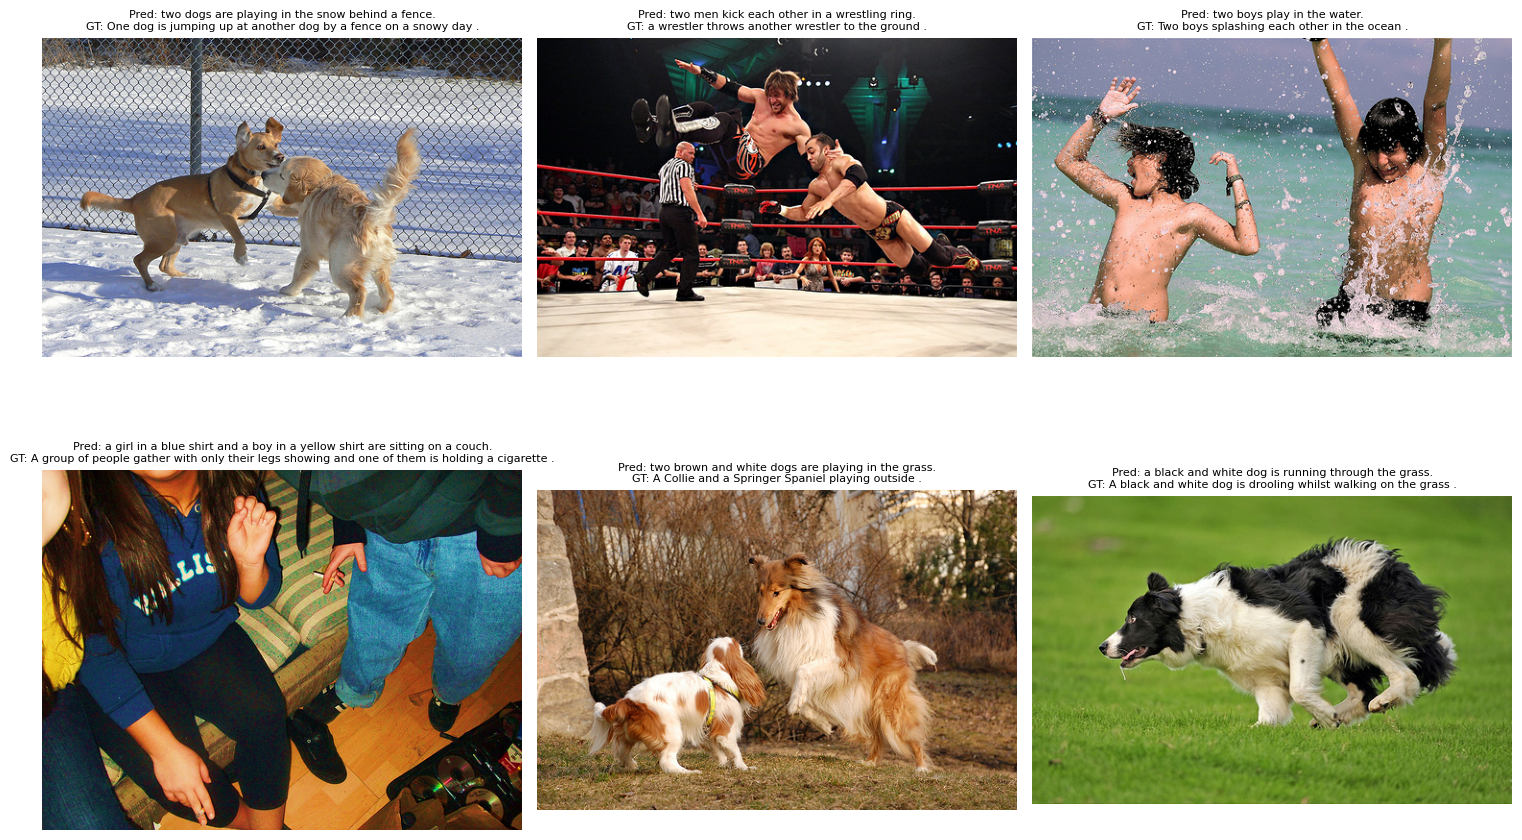

In [ ]:
show_grid_with_gt(model, df_small, refs, num_samples=6, cols=3)